In [1]:
import os
# The jupyter notebook is launched from your $HOME directory.
# Change the working directory to your username directory under /scratch/cd82
os.chdir(os.path.expandvars("/scratch/cd82/$USER/"))

# Image Classification with Convolutional Neural Networks

## Episode 05 Evaluate a Convolutional Neural Network and Make Predictions (Classifications)

## Step 9. Tune hyperparameters

## CHALLENGE Tune Activation Function using For Loop


In [2]:
# load the required packages
from tensorflow import keras # data and neural network
from sklearn.model_selection import train_test_split # data splitting
import matplotlib.pyplot as plt # plotting

2025-08-19 20:15:58.703404: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-19 20:15:59.391469: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-19 20:16:01.643280: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-19 20:16:01.656175: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-19 20:16:23.671445: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [3]:
# function to prepare the training dataset
def prepare_dataset(train_images, train_labels):
    
    # normalize the RGB values to be between 0 and 1
    train_images = train_images / 255.0
    
    # one hot encode the training labels
    train_labels = keras.utils.to_categorical(train_labels, len(class_names))
    
    # split the training data into training and validation set
    train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size = 0.2, random_state=42)

    return train_images, val_images, train_labels, val_labels

In [4]:
# load the data
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

# create a list of class names associated with each CIFAR-10 label
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# prepare the dataset for training
train_images, val_images, train_labels, val_labels = prepare_dataset(train_images, train_labels)

## Step 9. Tune hyperparameters

Hyperparameters are the parameters set by the person configuring the model instead of those learned by the algorithm itself. Like the dials on a radio which are tuned to the best frequency, hyperparameters can be tuned to the best combination for a given model and context.


## CHALLENGE Tune Activation Function using For Loop

Write some code to assess activation function performance.

Hint 1: Use the create_model_intro() definition as the build function to use during GridSearch. Make modifications to take a single parameter ‘activation_function and this time include the ’Model.compile()’ method call in the definition.


In [5]:
## SOLUTION


In [6]:
# modify the intro model to sample activation functions
def create_model_act(activation_function):

    # CNN Part 1
    # Input layer of 32x32 images with three channels (RGB)
    inputs_act = keras.Input(shape=train_images.shape[1:])
    
    # CNN Part 2
    # Convolutional layer with 16 filters, 3x3 kernel size, and ReLU activation
    x_act = keras.layers.Conv2D(filters=16, kernel_size=(3,3), activation=activation_function)(inputs_act)
    # Pooling layer with input window sized 2x2
    x_act = keras.layers.MaxPooling2D((2, 2))(x_act)
    # Second Convolutional layer with 32 filters, 3x3 kernel size, and ReLU activation
    x_act = keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation=activation_function)(x_act)
    # Second Pooling layer with input window sized 2x2
    x_act = keras.layers.MaxPooling2D(pool_size=(2,2))(x_act)
    # Flatten layer to convert 2D feature maps into a 1D vector
    x_act = keras.layers.Flatten()(x_act)
    # Dense layer with 64 neurons and ReLU activation
    x_act = keras.layers.Dense(units=64, activation=activation_function)(x_act)
    
    # CNN Part 3
    # Output layer with 10 units (one for each class) and softmax activation
    outputs_act = keras.layers.Dense(units=10, activation='softmax')(x_act)
    
    # create the model
    model_act = keras.Model(inputs = inputs_act, 
                              outputs = outputs_act, 
                              name="cifar_model_activation")
    
    # compile the model
    model_act.compile(optimizer = keras.optimizers.Adam(),
                      loss = keras.losses.CategoricalCrossentropy(),
                      metrics = keras.metrics.CategoricalAccuracy())

    return model_act

In [7]:
# create a ist of activation functions to try
activations = ['relu', 'sigmoid', 'tanh', 'selu', keras.layers.LeakyReLU()]

# create a dictionary object to store the training history
history_data = {} # dictionary

# train the model with each activation function and store the history
for activation in activations:
    
    # create the model
    model = create_model_act(activation)
    
    # fit the model
    history = model.fit(x = train_images, y = train_labels,
                        batch_size = 32,
                        epochs = 10, 
                        validation_data = (val_images, val_labels))
    
    # add training history to dictionary
    history_data[str(activation)] = history


2025-08-19 20:17:17.542809: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/10
1250/1250 [==============================] - 8s 5ms/step - loss: 1.5931 - categorical_accuracy: 0.4214 - val_loss: 1.3241 - val_categorical_accuracy: 0.5339
Epoch 2/10
1250/1250 [==============================] - 6s 5ms/step - loss: 1.2661 - categorical_accuracy: 0.5530 - val_loss: 1.2174 - val_categorical_accuracy: 0.5691
Epoch 3/10
1250/1250 [==============================] - 6s 5ms/step - loss: 1.1458 - categorical_accuracy: 0.5965 - val_loss: 1.1163 - val_categorical_accuracy: 0.6184
Epoch 4/10
1250/1250 [==============================] - 5s 4ms/step - loss: 1.0637 - categorical_accuracy: 0.6290 - val_loss: 1.0619 - val_categorical_accuracy: 0.6323
Epoch 5/10
1250/1250 [==============================] - 5s 4ms/step - loss: 1.0038 - categorical_accuracy: 0.6474 - val_loss: 1.0503 - val_categorical_accuracy: 0.6377
Epoch 6/10
1250/1250 [==============================] - 5s 4ms/step - loss: 0.9553 - categorical_accuracy: 0.6669 - val_loss: 1.0655 - val_categorical_accuracy:

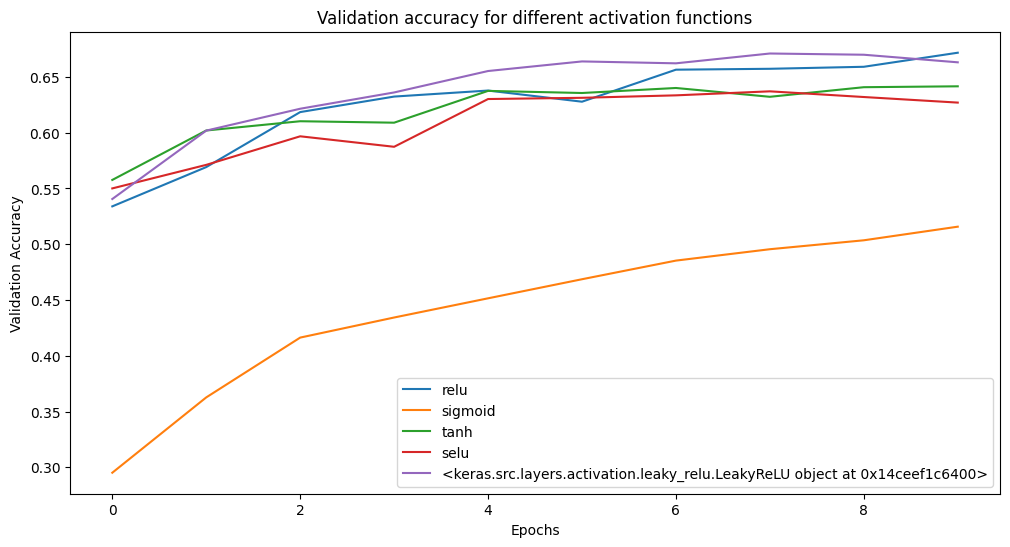

In [8]:
# plot the validation accuracy for each activation function
plt.figure(figsize=(12, 6))

for activation, history in history_data.items():
    plt.plot(history.history['val_categorical_accuracy'], label=activation)

plt.title('Validation accuracy for different activation functions')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()